## Loaging basic libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

## Data cleaning

In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
# Droping ID column
df = df.drop(columns=['Loan_ID'])

In [7]:
# Seperating Numerical and Categorical columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

In [8]:
df[num_cols].isnull().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

In [9]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median(), inplace=True)

In [10]:
df[cat_cols].isnull().sum()  

Gender           13
Married           3
Dependents       15
Education         0
Self_Employed    32
Property_Area     0
Loan_Status       0
dtype: int64

In [11]:
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [12]:
# There is much difference in the distribution of numerical columns. So we will use boxplot to find outliers. and then we will use IQR method to remove outliers.

for col in num_cols:
    Q1= df[col].quantile(0.10)
    Q3= df[col].quantile(0.90)
    IQR= Q3 - Q1
    lower_bound= Q1 - 1.5 * IQR
    upper_bound= Q3 + 1.5 * IQR
    df= df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

### EDA

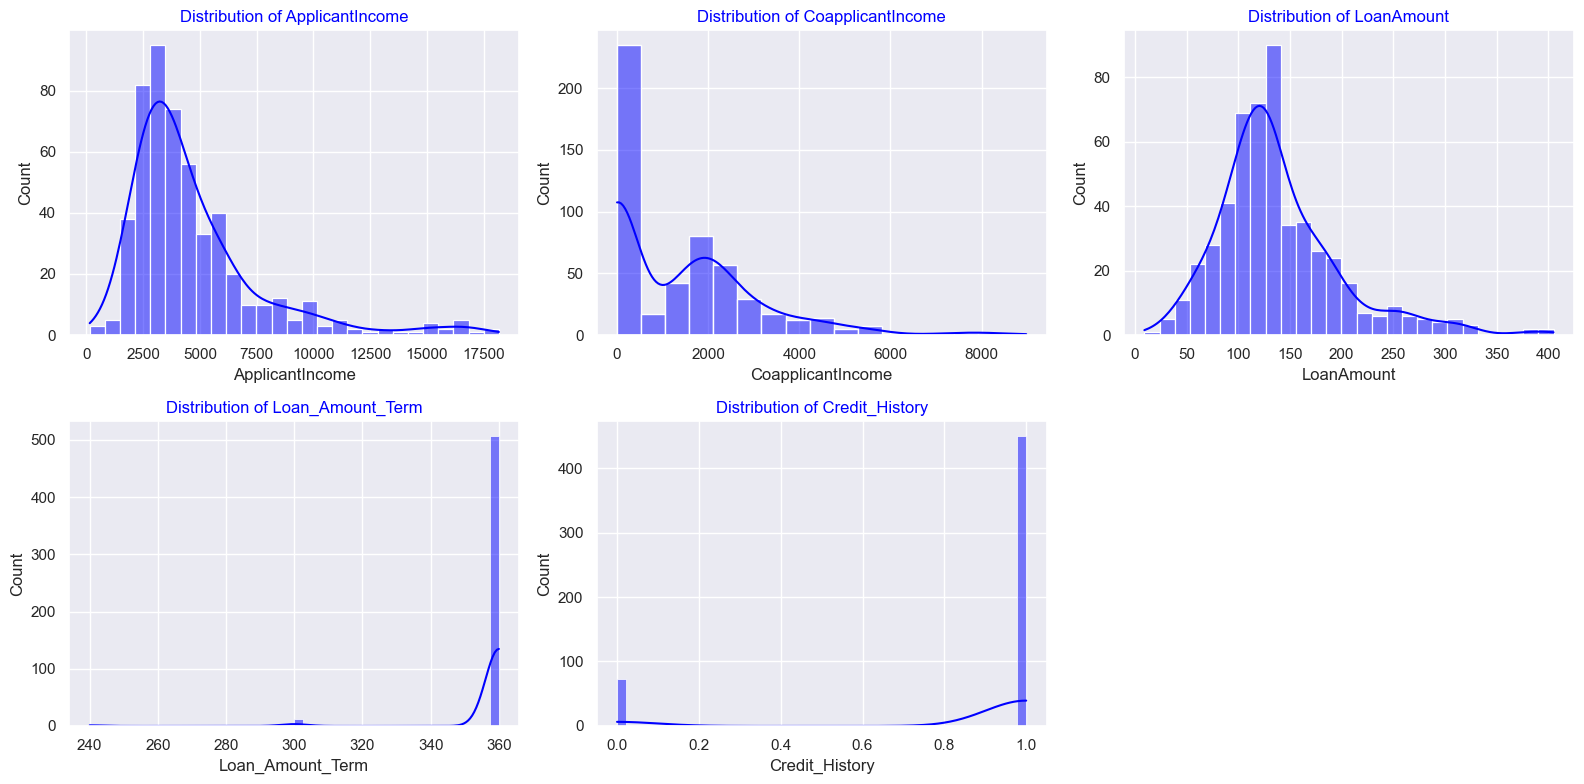

In [13]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(16,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color="blue")
    plt.title(f'Distribution of {col}', color="Blue")

plt.tight_layout()
plt.show()

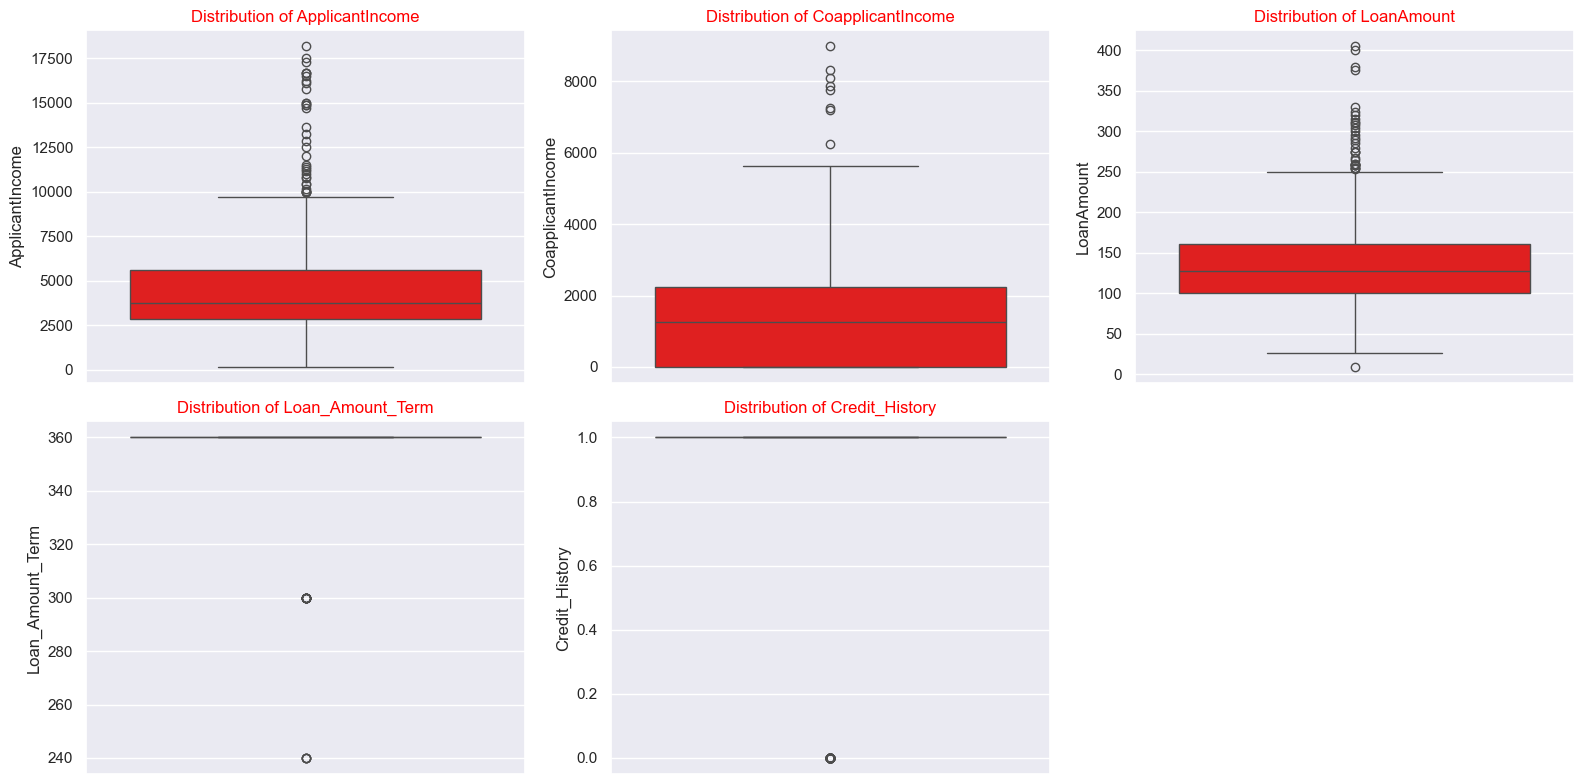

In [14]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(16,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(df[col],color="red")
    plt.title(f'Distribution of {col}', color="red")

plt.tight_layout()
plt.show()

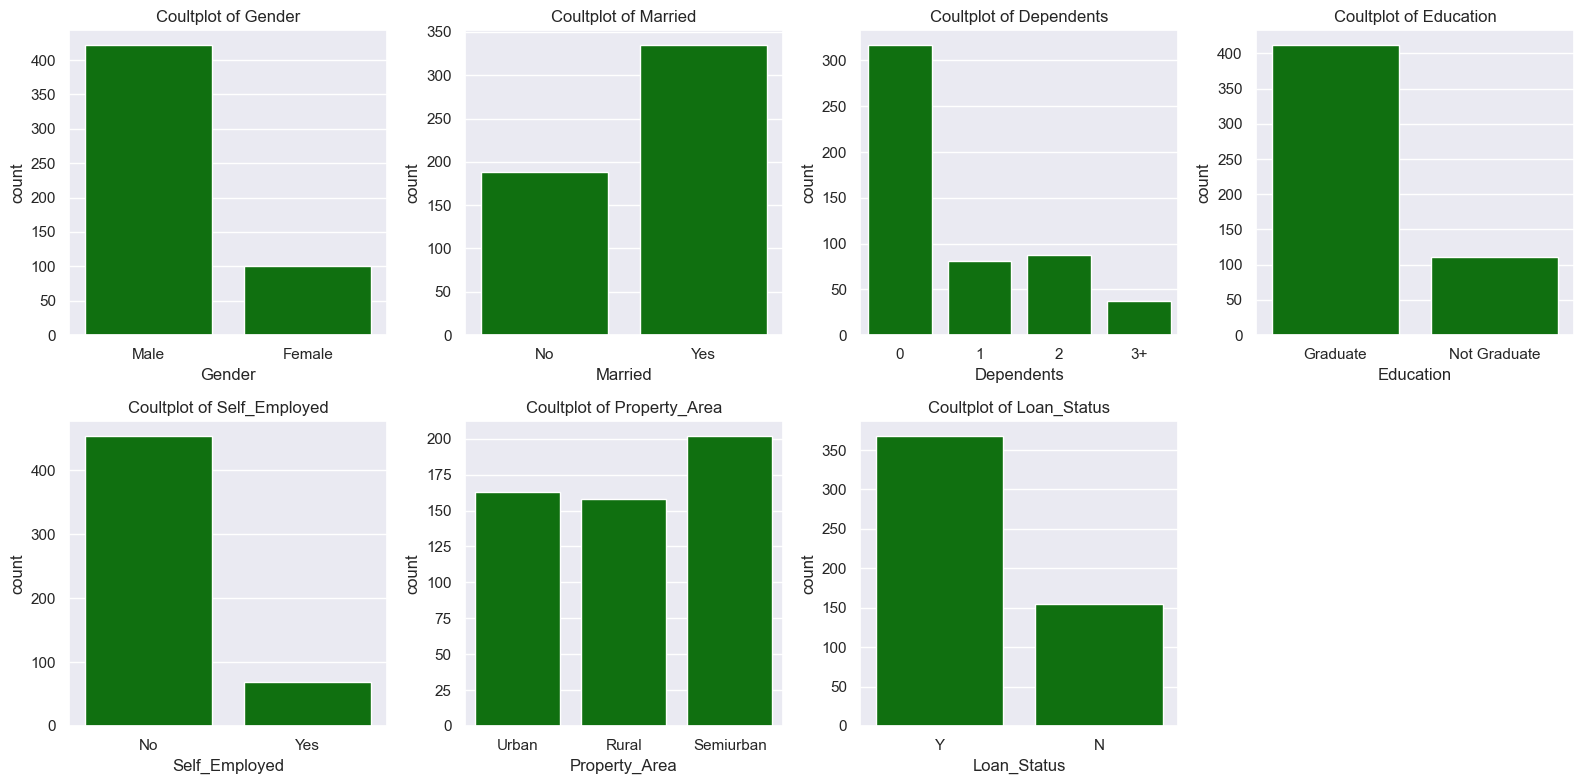

In [15]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(16,8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 4, i)
    sns.countplot(x= df[col],color="green")
    plt.title(f'Coultplot of {col}')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [16]:
# We have to convert our cat_cols in numerical value, here using OneHotEncoding
# But there is two feature named Dependents and Property_Area which has 4type of data, so LabelEncoding is applied for this feature

# remove specific columns from categorical list
cat_cols = [col for col in cat_cols if col not in ['Dependents', 'Property_Area']]

# one-hot encode remaining categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# label encode selected columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Dependents'] = le.fit_transform(df['Dependents'])
df['Property_Area'] = le.fit_transform(df['Property_Area'])

In [17]:
# Creating new feature
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
# Dropping the original income columns
df = df.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1)

In [18]:
df.head(2)

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Loan_Status_Y,Total_Income
0,0,128.0,360.0,1.0,2,True,False,False,False,True,5849.0
1,1,128.0,360.0,1.0,0,True,True,False,False,False,6091.0


In [19]:
# Renaming all the columns with easily understandable name
df.rename(columns={
    'Gender_Male': "Gender",
    'Married_Yes': "Married",
    'Education_Not Graduate':'Graduate',
    'Self_Employed_Yes':'Self_Employed',
    'Loan_Status_Y': "Load_Status"
}, inplace=True)

In [20]:
# Converting our dataset into integer
df = df.astype(int)

## Spliting the dataset

In [21]:
X = df.drop('Load_Status',axis=1)
y = df['Load_Status']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.07, random_state=42)

# 2. Scaling (Fit on Train, Transform on Test)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Here we will find which model is performing good in our dataset and we will choose bese one to make final model.

In [23]:
# Importing necessary model to check which is working good in out dataset

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

# 3. Model Dictionary, KNN and XGBoost need to fix some parameter...
models = {
    'log_model': LogisticRegression(),
    'rf_model': RandomForestClassifier(),
    'svm_model': SVC(),
    'knn_model': KNeighborsClassifier(n_neighbors=5),
    'nb_model': GaussianNB(),
    'xgb_model': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [24]:
# 4. Evaluation Loop with Cross-Validation
print(f"{'Model':<15} | {'CV Mean Acc':<12} | {'Test Acc':<10}")
print("-" * 45)

for name, model in models.items():
    # Perform 5-fold Cross-Validation on the training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    # Fit on the full training set to check performance on the hold-out test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    
    print(f"{name:<15} | {cv_mean:<12.4f} | {test_acc:<10.4f}")

# Since the dataset is too short, powerful algorithm is not good results.

Model           | CV Mean Acc  | Test Acc  
---------------------------------------------
log_model       | 0.8272       | 0.7838    
rf_model        | 0.8005       | 0.6757    
svm_model       | 0.8210       | 0.7838    
knn_model       | 0.7922       | 0.6757    
nb_model        | 0.8127       | 0.7838    
xgb_model       | 0.7675       | 0.6216    


### Now we will use Logistic Regression algorithm  or svc algorithm... Both giving same accuracy rate

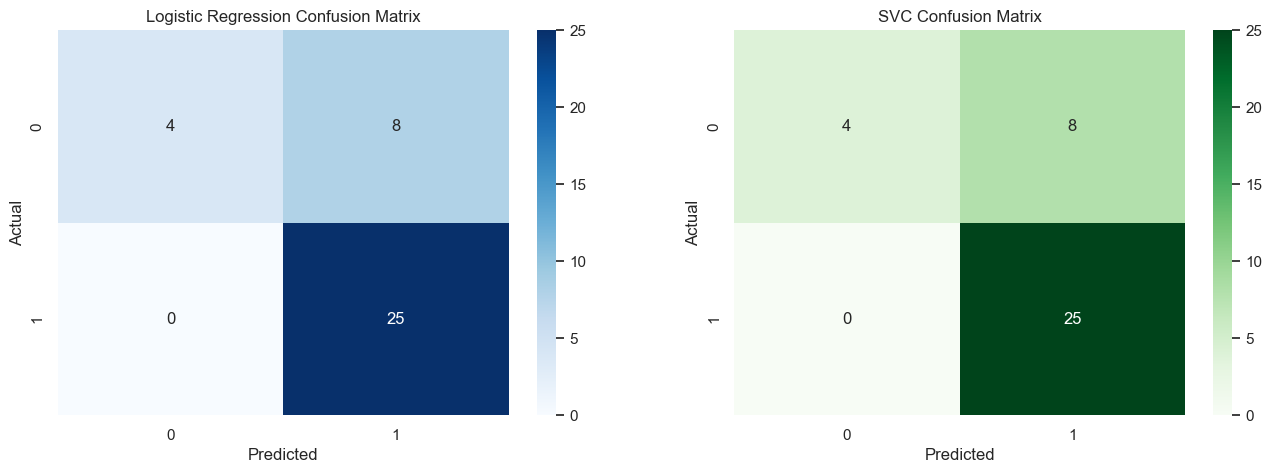

In [25]:
plt.figure(figsize=(16,5))

# Plot 1: Logistic Regression
plt.subplot(1,2,1)
# You are using class_weight='balanced' to handle the target distribution imbalance
log_model = LogisticRegression(class_weight='balanced') 
log_model.fit(X_train, y_train)
log_y_pred = log_model.predict(X_test)
log_con = confusion_matrix(y_test, log_y_pred)
sns.heatmap(log_con, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot 2: Support Vector Classifier (Fixed Variable Name)
plt.subplot(1,2,2)
# Renamed from nb_model to svc_model for clarity
svc_model = SVC(class_weight='balanced') 
svc_model.fit(X_train, y_train)
svc_y_pred = svc_model.predict(X_test)
svc_con = confusion_matrix(y_test, svc_y_pred)
sns.heatmap(svc_con, annot=True, fmt='d', cmap='Greens')
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Hyperparameter Tuning

In [27]:
from sklearn.model_selection import GridSearchCV


classifier = GridSearchCV(log_model,{ 
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'], # l1= Lasso and l2= Ridge 
    'solver': ['liblinear'],
    'max_iter': [50, 100]
}, cv=5, return_train_score=False)

classifier.fit(X_train, y_train)

# View results
results = pd.DataFrame(classifier.cv_results_)
print(results[['param_C', 'param_penalty','param_solver','param_max_iter', 'mean_test_score']])

    param_C param_penalty param_solver  param_max_iter  mean_test_score
0       0.1            l1    liblinear              50         0.827162
1       0.1            l2    liblinear              50         0.816874
2       0.1            l1    liblinear             100         0.827162
3       0.1            l2    liblinear             100         0.816874
4       1.0            l1    liblinear              50         0.812750
5       1.0            l2    liblinear              50         0.806564
6       1.0            l1    liblinear             100         0.812750
7       1.0            l2    liblinear             100         0.806564
8      10.0            l1    liblinear              50         0.806564
9      10.0            l2    liblinear              50         0.806564
10     10.0            l1    liblinear             100         0.806564
11     10.0            l2    liblinear             100         0.806564
12    100.0            l1    liblinear              50         0

### Here, we just got our parameter values which are giving best accuracy

# Final Model

In [28]:
model= LogisticRegression(C=0.1, penalty="l1", solver='liblinear',max_iter=50)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [29]:
# Final prediction
y_pred= model.predict(X_test)

 Final Accuracy Score: 0.7837837837837838

Final Confusion Matrix:


<Axes: >

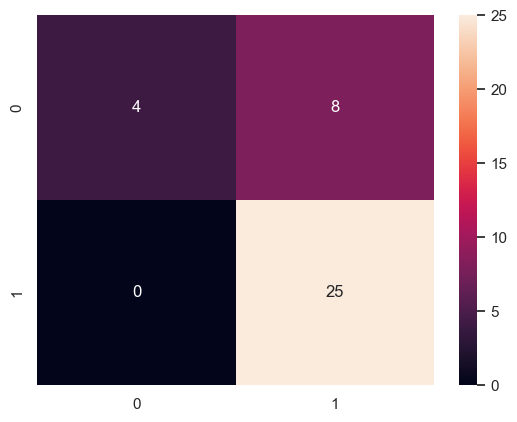

In [32]:
# See the accuracy of tuned model
print(f" Final Accuracy Score: {accuracy_score(y_test, y_pred)}")

# See the Confusion Matrix for the tuned model
print("\nFinal Confusion Matrix:")
con= confusion_matrix(y_test, y_pred)
sns.heatmap(con, annot=True)

### Our accuracy is unchanged!
#### This is a small dataset and model is over depending on a feature, that's why after tuning accuracy score is unchanged
## But confusion matrix changes littel bit...and it changes the precison

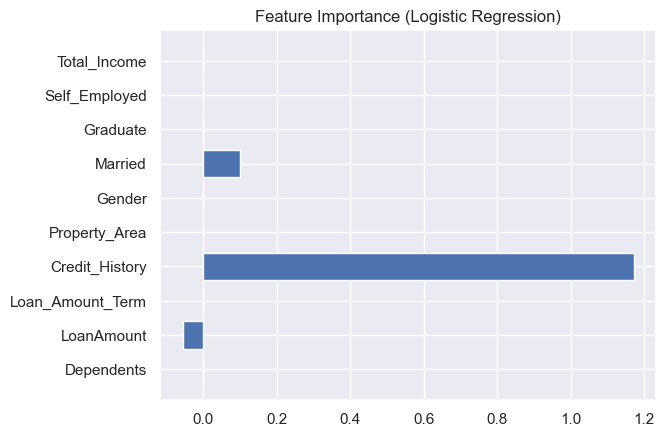

In [31]:
# FINDING FEATURE IMPORTANCE
# Get the importance of each feature
best_log_model = classifier.best_estimator_
importance = best_log_model.coef_[0]
feature_names = X.columns # Assuming X is your dataframe before scaling

# Plot it
plt.barh(feature_names, importance)
plt.title("Feature Importance (Logistic Regression)")
plt.show()